## OVERVIEW
* The hotel booking dataset provides comprehensive information on reservations made at two types of hotels: city hotels and resort hotels. It includes details such as booking dates, stay durations, customer demographics, pricing, and cancellation status. Through this data, one can observe patterns in customer behavior, seasonal booking trends, and differences in hotel performance. Overall, the dataset offers valuable insights into operational, marketing, and pricing strategies that can enhance hotel management and customer satisfaction.

### IMPORTING LIBRARIES

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv(r"C:\Users\ASUS\Downloads\data science\hotel_bookings.csv")
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [3]:
df.size

3820480

In [4]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [5]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [7]:
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [8]:

df['country'].fillna('other',inplace=True)

In [9]:
df['agent'].fillna(df['agent'].mean(),inplace=True)

In [10]:
df['company'].fillna(df['company'].mean(),inplace=True)

In [11]:
df.duplicated().sum()

31994

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,87396.0,0.274898,0.446466,0.00,0.000000,0.000000,1.000000,1.0
lead_time,87396.0,79.891368,86.052325,0.00,11.000000,49.000000,125.000000,737.0
arrival_date_year,87396.0,2016.210296,0.686102,2015.00,2016.000000,2016.000000,2017.000000,2017.0
arrival_date_week_number,87396.0,26.838334,13.674572,1.00,16.000000,27.000000,37.000000,53.0
arrival_date_day_of_month,87396.0,15.815541,8.835146,1.00,8.000000,16.000000,23.000000,31.0
stays_in_weekend_nights,87396.0,1.005263,1.031921,0.00,0.000000,1.000000,2.000000,19.0
stays_in_week_nights,87396.0,2.625395,2.053584,0.00,1.000000,2.000000,4.000000,50.0
adults,87396.0,1.875795,0.626500,0.00,2.000000,2.000000,2.000000,55.0
children,87392.0,0.138640,0.455881,0.00,0.000000,0.000000,0.000000,10.0
babies,87396.0,0.010824,0.113597,0.00,0.000000,0.000000,0.000000,10.0


## ANALYSING DATA


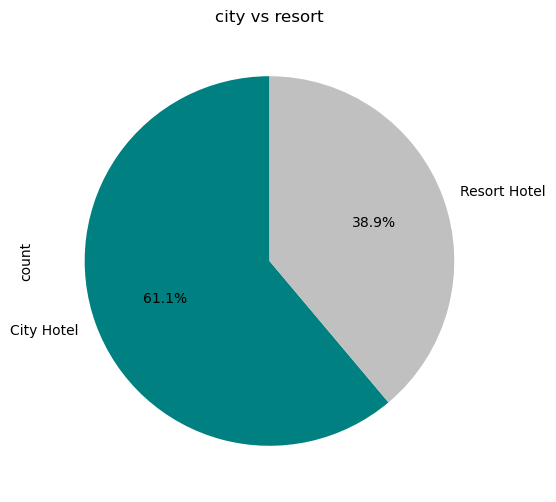

In [14]:
plt.figure(figsize=(10,6))
df['hotel'].value_counts().plot(kind='pie',autopct='%1.1f%%',colors=['teal','silver'],startangle=90)
plt.title('city vs resort')
plt.show()

### There have been more bookings in city hotels  than resort hotels

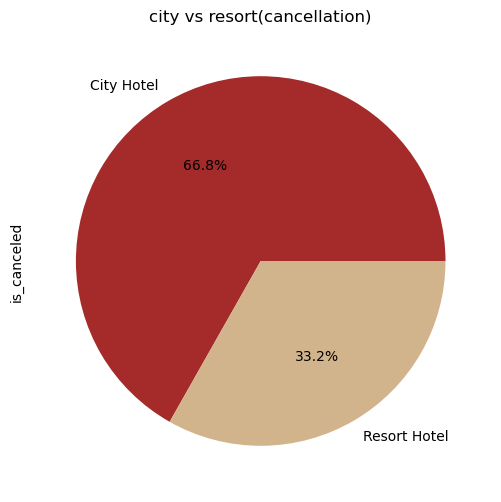

In [15]:
plt.figure(figsize=(10,6))
df.groupby('hotel')['is_canceled'].sum().plot(kind='pie',autopct='%1.1f%%',colors=['Brown','tan'])
plt.title('city vs resort(cancellation)')
plt.show()

### There have been more cancellation in city hotels than resort hotels

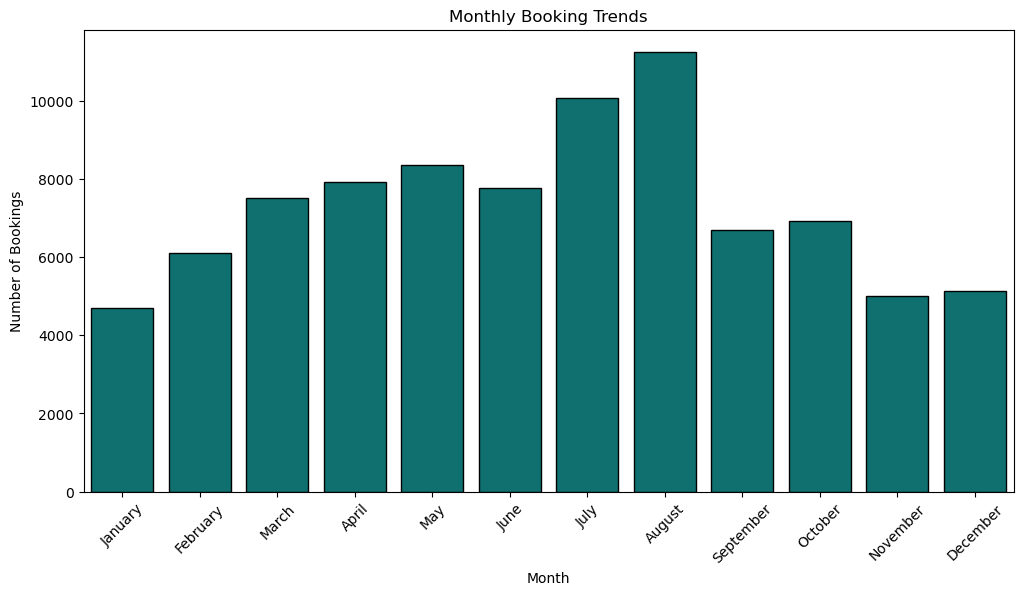

In [16]:
monthly_trend = df['arrival_date_month'].value_counts().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'])
plt.figure(figsize=(12,6))
sns.barplot(x=monthly_trend.index, y=monthly_trend.values,color='teal',edgecolor='black')
plt.title("Monthly Booking Trends")
plt.xlabel("Month")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

### The month of august had the highest hotel booking.

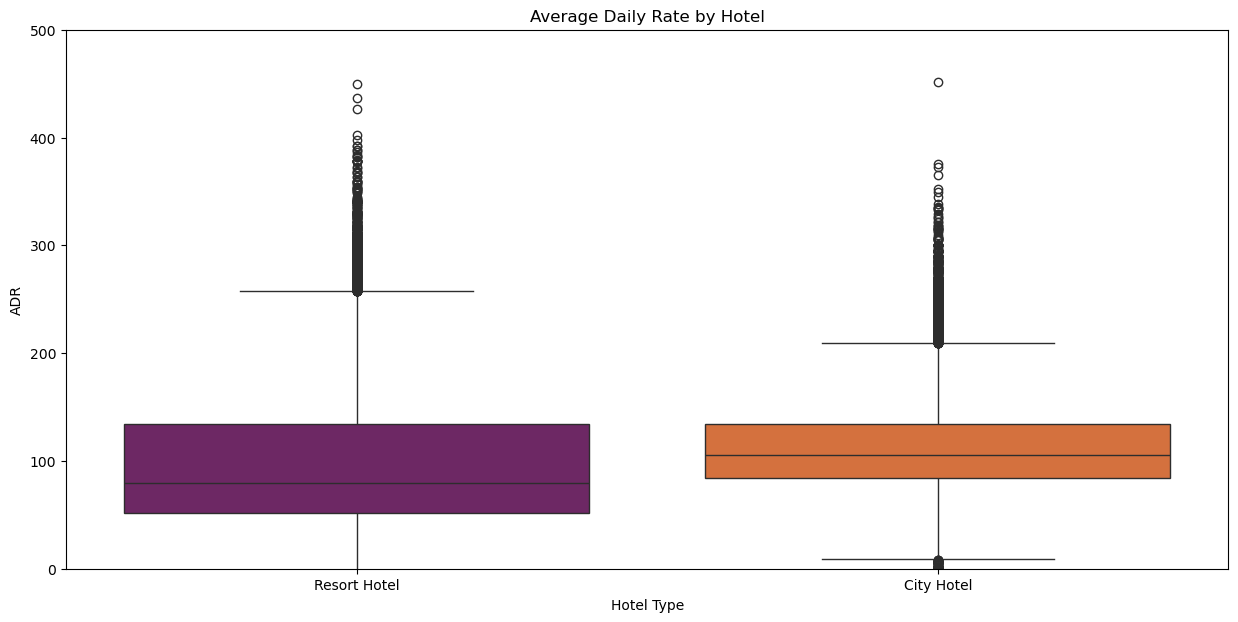

In [17]:
plt.figure(figsize=(15,7))
sns.boxplot(data=df, x="hotel", y="adr",palette='inferno')
plt.title("Average Daily Rate by Hotel")
plt.ylabel("ADR")
plt.xlabel("Hotel Type")
plt.ylim(0, 500)
plt.show()

### Resort Hotels tend to charge higher room rates on average compared to City Hotels.

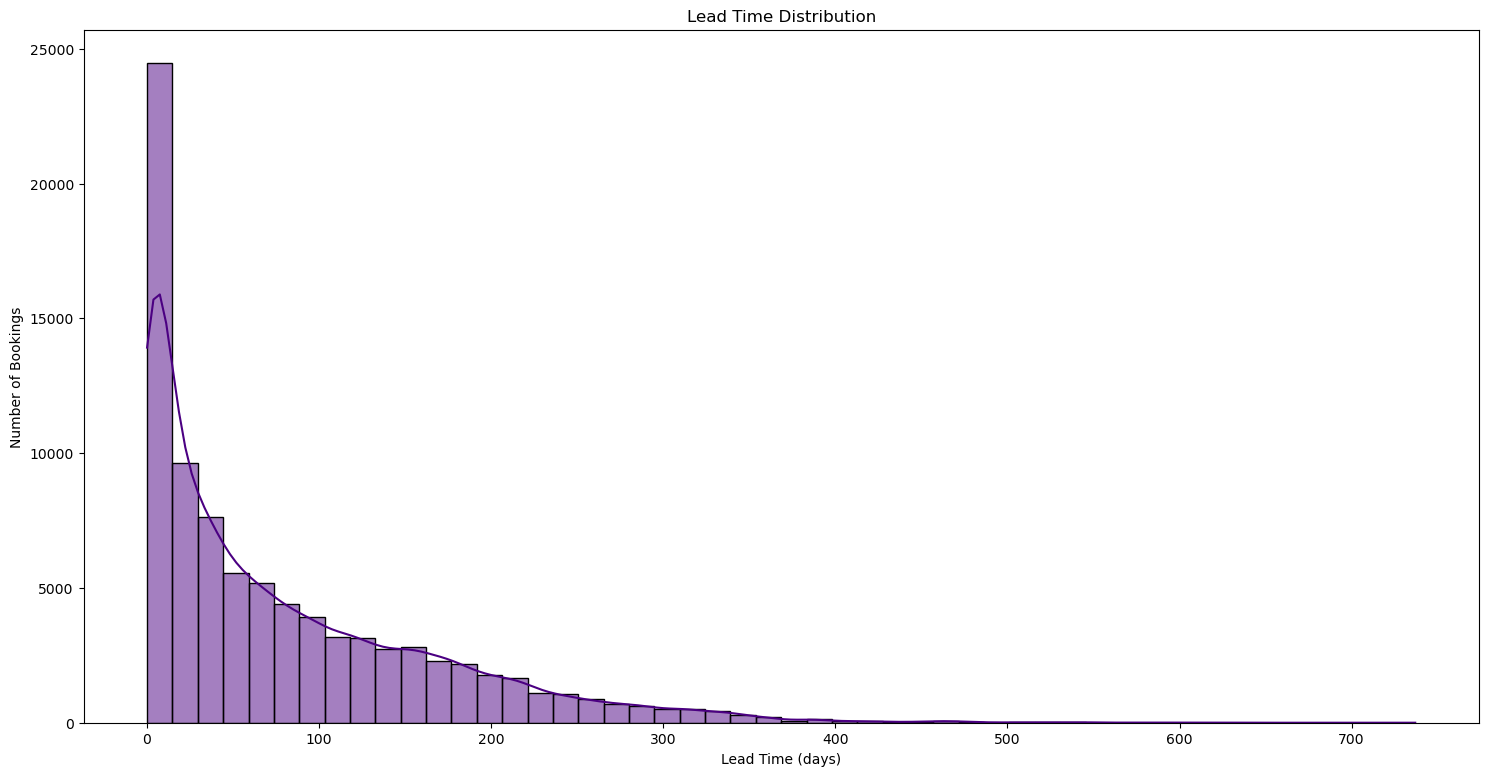

In [18]:
plt.figure(figsize=(18,9))
sns.histplot(df["lead_time"], bins=50, kde=True,color='indigo')
plt.title("Lead Time Distribution")
plt.xlabel("Lead Time (days)")
plt.ylabel("Number of Bookings")
plt.show()

### Most bookings are made well in advance, with a notable number of guests booking over 100 days ahead.

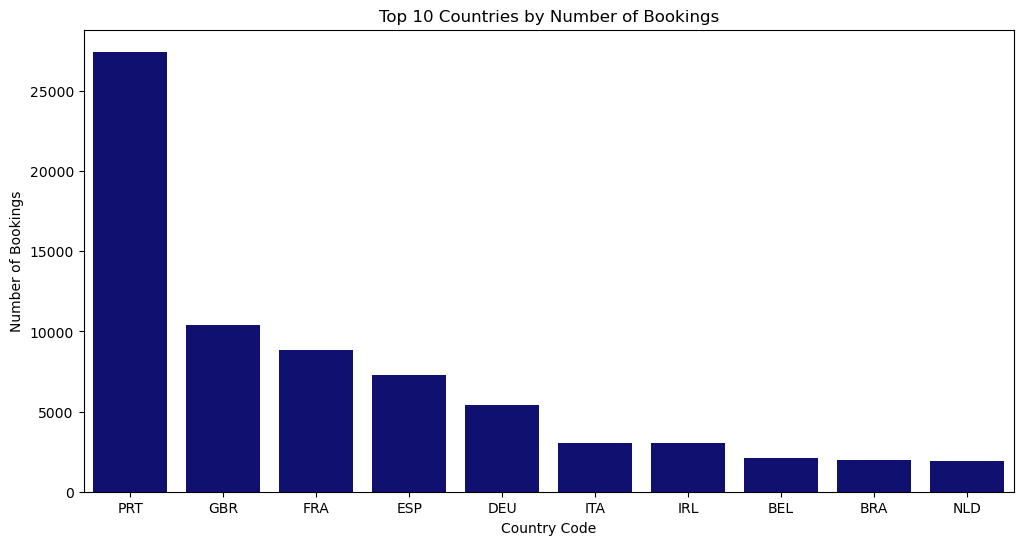

In [19]:
top_countries = df['country'].value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_countries.index, y=top_countries.values,color='navy')
plt.title("Top 10 Countries by Number of Bookings")
plt.xlabel("Country Code")
plt.ylabel("Number of Bookings")
plt.show()

### Portugal, the United Kingdom, and France are the top contributors to hotel bookings in this dataset.

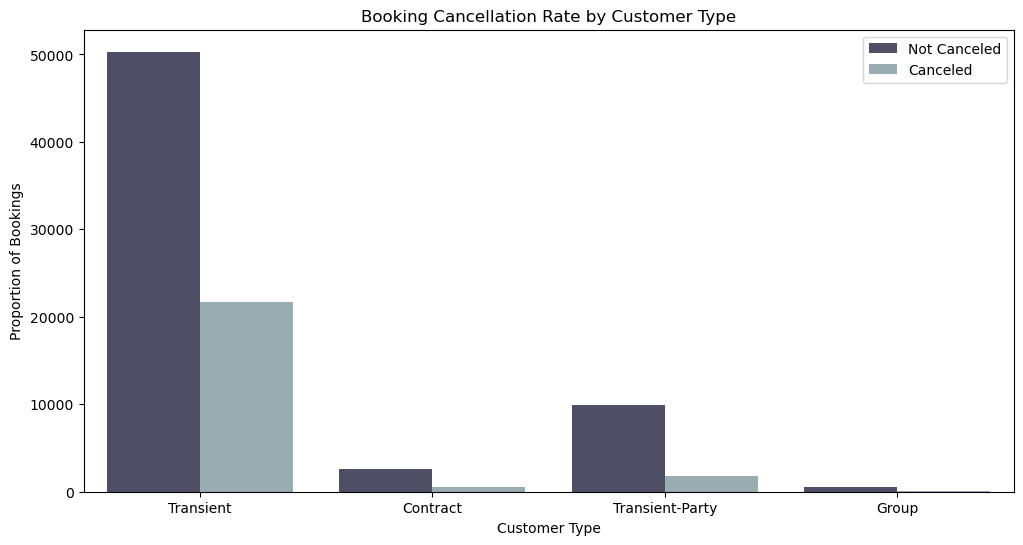

In [20]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="customer_type", hue="is_canceled", palette='bone')
plt.title("Booking Cancellation Rate by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Proportion of Bookings")
plt.legend(["Not Canceled", "Canceled"])
plt.show()

### Customers labeled as Transient exhibit the highest cancellation rates, indicating that individual travelers are more likely to cancel than group or corporate clients.

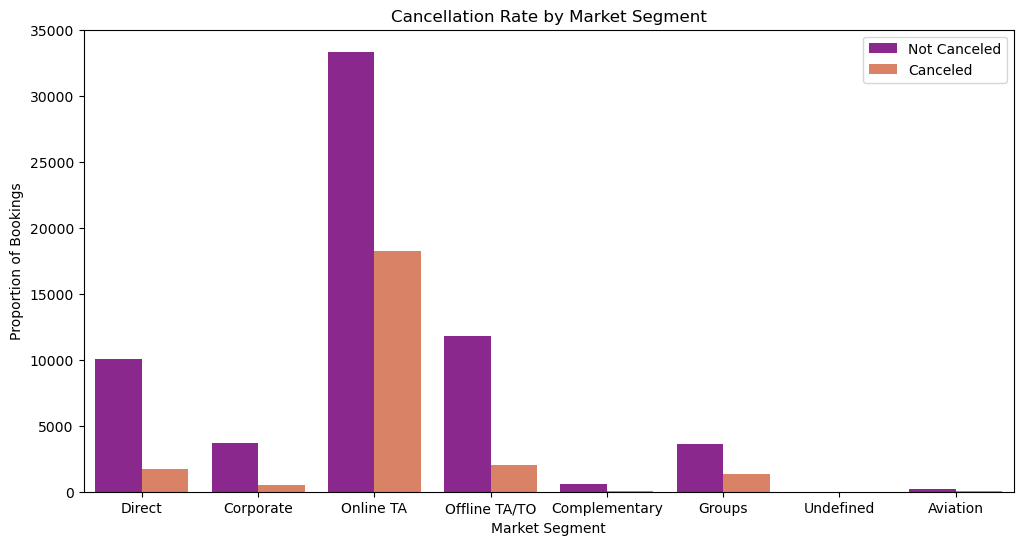

In [21]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="market_segment", hue="is_canceled",palette='plasma')
plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Proportion of Bookings")
plt.legend(["Not Canceled", "Canceled"])
plt.show()


### Online Travel Agents typically show higher cancellations than Corporate or Direct bookings.



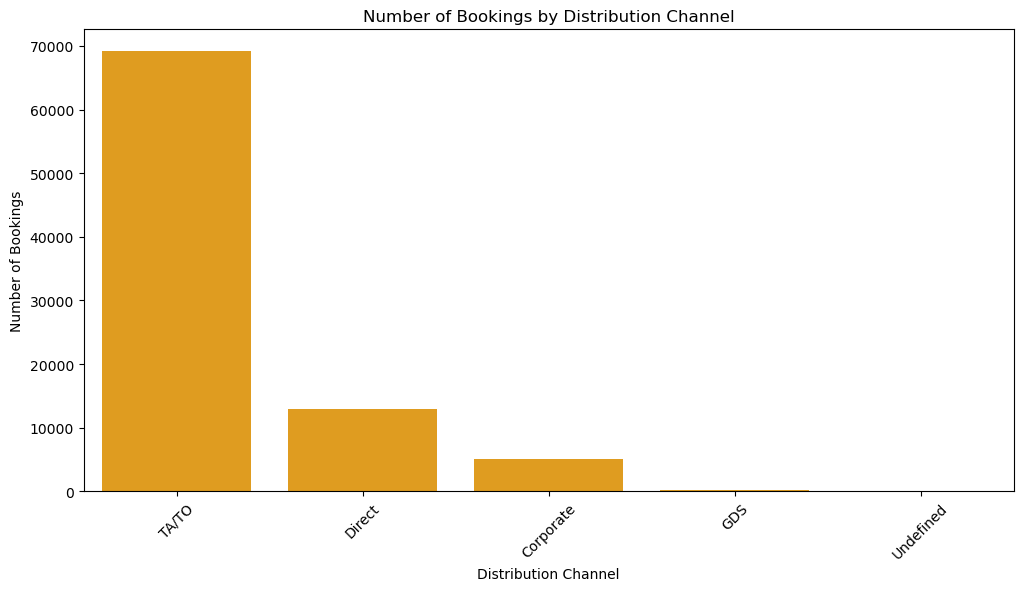

In [22]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='distribution_channel', order=df['distribution_channel'].value_counts().index,color='orange')
plt.title("Number of Bookings by Distribution Channel")
plt.xlabel("Distribution Channel")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.show()

### Most bookings are made through the "TA/TO" channel, highlighting its dominant role in hotel reservations.

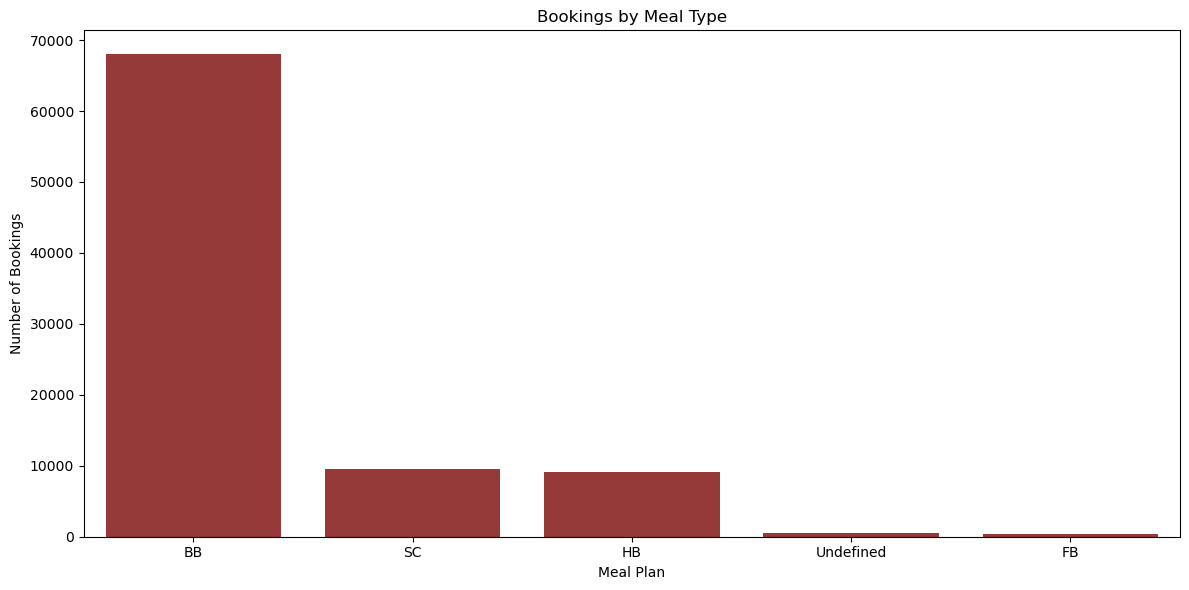

In [23]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x='meal', order=df['meal'].value_counts().index,color='brown')
plt.title("Bookings by Meal Type")
plt.xlabel("Meal Plan")
plt.ylabel("Number of Bookings")
plt.tight_layout()
plt.show()

### Most bookings opt for the Bed & Breakfast meal plan, suggesting it is the most popular and convenient option among travelers.



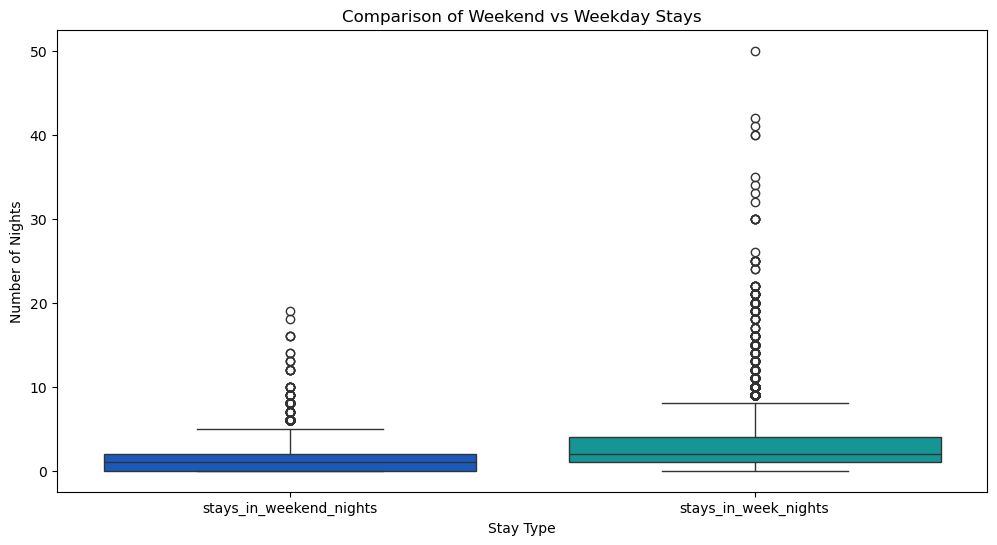

In [24]:
stays_df = df[["stays_in_weekend_nights", "stays_in_week_nights"]].melt(var_name="Stay Type", value_name="Nights")
plt.figure(figsize=(12,6))
sns.boxplot(data=stays_df, x="Stay Type", y="Nights",palette='winter')
plt.title("Comparison of Weekend vs Weekday Stays")
plt.xlabel("Stay Type")
plt.ylabel("Number of Nights")
plt.show()

### Guests typically stay longer on weekdays than weekends



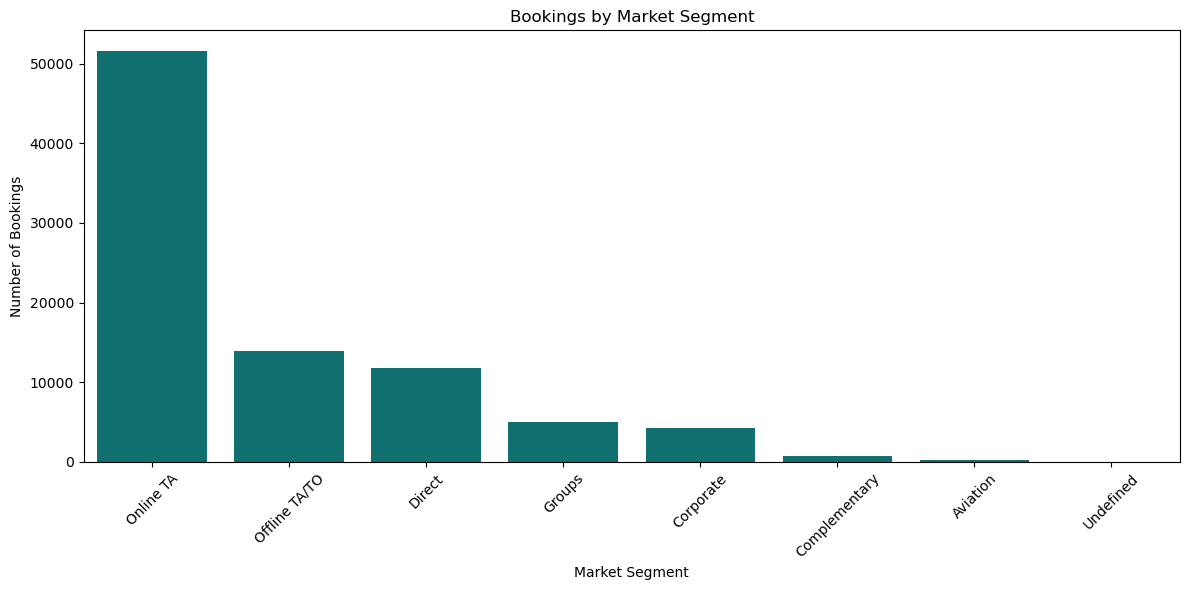

In [25]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="market_segment", order=df["market_segment"].value_counts().index,color='teal')
plt.title("Bookings by Market Segment")
plt.xlabel("Market Segment")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### The majority of bookings come from the 'Online TA' segment, highlighting the strong influence of online travel agencies on hotel occupancy.

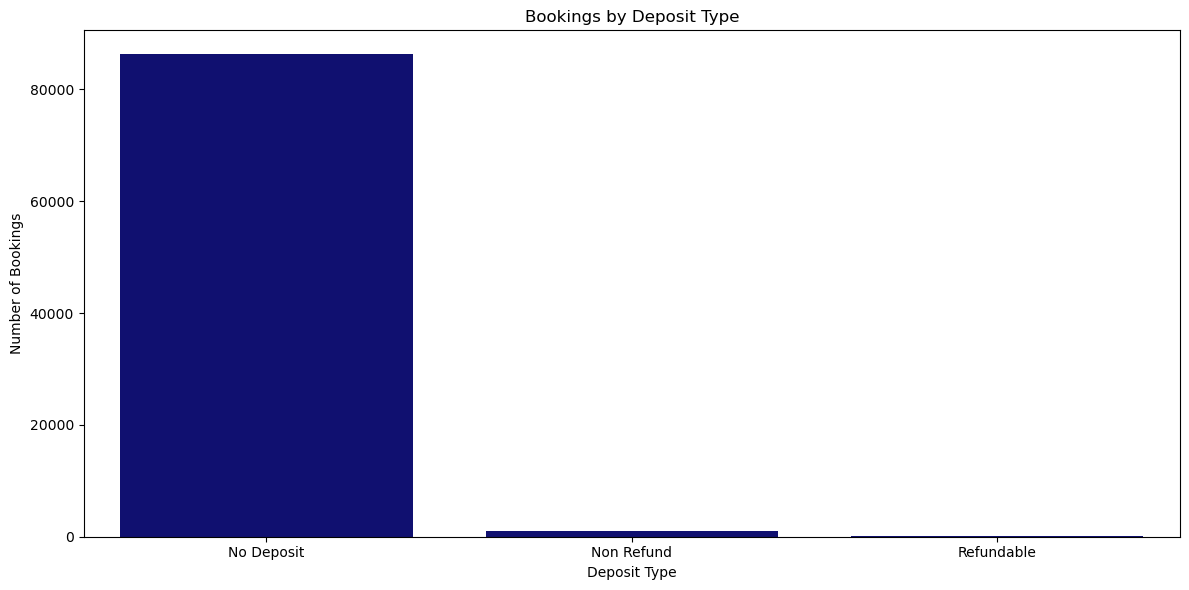

In [26]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="deposit_type", order=df["deposit_type"].value_counts().index,color='navy')
plt.title("Bookings by Deposit Type")
plt.xlabel("Deposit Type")
plt.ylabel("Number of Bookings")
plt.tight_layout()
plt.show()

### Most bookings are made with 'No Deposit', indicating flexible cancellation policies are preferred by guests.



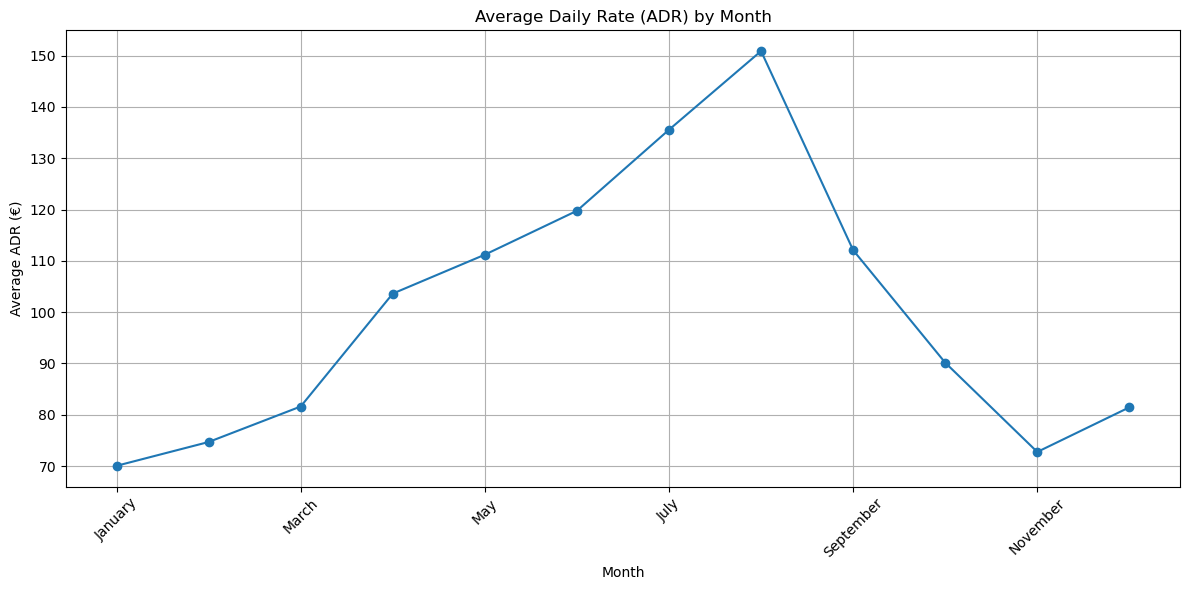

In [27]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_adr = df.groupby("arrival_date_month")["adr"].mean().reindex(month_order)
plt.figure(figsize=(12,6))
monthly_adr.plot(marker='o', linestyle='-')
plt.title("Average Daily Rate (ADR) by Month")
plt.xlabel("Month")
plt.ylabel("Average ADR (€)")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### ADR peaks during  August, indicating higher prices during peak tourist season.

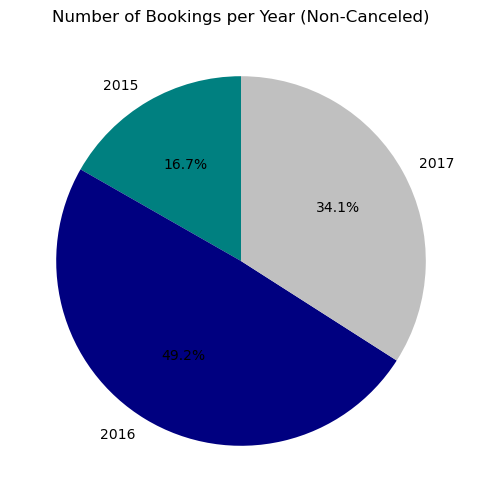

In [35]:
bookings_per_year = df[df['is_canceled'] == 0]['arrival_date_year'].value_counts().sort_index()
plt.figure(figsize=(12,6))
plt.pie(bookings_per_year, labels=bookings_per_year.index, autopct='%1.1f%%', startangle=90,colors=['teal','navy','silver'])
plt.title('Number of Bookings per Year (Non-Canceled)')
plt.show()

### The majority of non-canceled hotel bookings occurred in 2016 and 2017, indicating peak customer engagement during those years.

## CONCLUSION
* City Hotels Dominate Bookings, A larger proportion of total bookings are made in city hotels compared to resort hotels.
* Higher Cancellations in City Hotels, Despite having more bookings, city hotels also face a higher number of cancellations than resort hotels.
* August Sees Peak Bookings, August records the highest number of hotel bookings, indicating a strong seasonal demand during this month.
* Resort Hotels Have Higher ADR, The Average Daily Rate (ADR) is generally higher in resort hotels, suggesting they cater to a more premium or seasonal clientele.
* Lead Time Varies Widely, There is a broad distribution in lead time, with some bookings made far in advance, indicating varied planning behavior among customers.
* Booking Trends are Seasonal, Monthly booking trends show fluctuations, emphasizing the importance of seasonal marketing and resource planning.
* Most bookings are made through the "TA/TO" channel, highlighting its dominant role in hotel reservations.